In [1]:
#other imports
import os
import numpy as np
import scipy as sp
os.chdir('C:/Code/Github/GLM-analysis/')

In [188]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun
from DecoderAnalyzer import DecoderAnalyzer as analysisdec
from AnalysisManagerEncoding import AnalysisManagerEncoding as analysisenc

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
#decoded_variables= { 'photostim', 'shuffled/photostim'}
decoded_variables= { 'photostim', 'shuffled/photostim'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed
data_handler_pass = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [168]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

#remove_indices = [8,22] #NO SOUND/CHOICE
remove_indices = [24] #[2,8,11,22,23,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)
#remove_indices = [2,7,8,20,21,22] #NO OUTCOME

##remove_indices =  [0,1,3,4,5,6,7,9,10,12,13,14,15,16,17,18,19,20,21,22,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)


#remove_indices = [0,1,2,4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] testing with 2 datasets

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA11-1R', '2023-05-05', 'V:')
('HA11-1R', '2023-04-13', 'V:')
('HA2-1L', '2023-04-12', 'V:')
('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-06-29', 'V:')
('HA1-00', '2023-08-28', 'W:')
('HE4-1L1R', '2023-08-21', 'W:')
('HE4-1L1R', '2023-08-24', 'W:')
('HA10-1L', '2023-04-10', 'V:')
('HA10-1L', '2023-04-17', 'V:')
('HA10-1L', '2023-04-12', 'V:')
('HA11-1R', '2023-04-07', 'V:')
('HA11-1R', '2023-05-01', 'V:')
('HA11-1R', '2023-05-02', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA2-1L', '2023-05-01', 'V:')
('HA1-00', '2023-06-27', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA1-00', '2023-08-25', 'W:')
('HE4-1L1R', '2023-08-14', 'W:')
('HE4-1L1R', '2023-08-28', 'W:')
('HE4-1L1R', '2023-09-04', 'W:')
('HE4-1L1R', '2023-09-11', 'W:')
('HA10-1L', '2023-03-31', 'V:')


In [169]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)
cat_results = []
cat_results_pass = []

model_type = 'GLM_3nmf_pre'
results_pre,results_pre_all_sb, cat_results, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop

model_type = 'GLM_3nmf_passive'
results_pass,results_pass_all_sb, cat_results_pass, celltype_info = data_handler_pass.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA11-1R_2023-05-05
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/1_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/2_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/3_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/4_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/5_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/6_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/7_1/
decoder_r

In [170]:
def save_process_multiple_datasets_output(output, filename):
    """
    Save the output of process_multiple_datasets to a file using pickle.
    
    Parameters:
    - output: The output of process_multiple_datasets
    - filename: str, the filename to save the output
    """
    with open(filename, 'wb') as file:
        pickle.dump(output, file)
    print(f"Output saved to {filename}")

In [172]:
import pickle
#save as pickled files so we can load them faster?
save_process_multiple_datasets_output(results_pre, os.path.join(save_results, 'results_pre.pkl'))
save_process_multiple_datasets_output(results_pre, os.path.join(save_results, 'results_pre_all_sb.pkl'))
save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass.pkl'))
save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass_all_sb.pkl'))
save_process_multiple_datasets_output(cat_results, os.path.join(save_results, 'cat_results.pkl'))
save_process_multiple_datasets_output(cat_results_pass, os.path.join(save_results, 'cat_results_pass.pkl'))
save_process_multiple_datasets_output(celltype_info, os.path.join(save_results, 'celltype_info.pkl'))


Output saved to V:/Connie/results/glm_decoding/prelim\results_pre.pkl
Output saved to V:/Connie/results/glm_decoding/prelim\results_pre_all_sb.pkl
Output saved to V:/Connie/results/glm_decoding/prelim\results_pass.pkl
Output saved to V:/Connie/results/glm_decoding/prelim\results_pass_all_sb.pkl
Output saved to V:/Connie/results/glm_decoding/prelim\cat_results.pkl
Output saved to V:/Connie/results/glm_decoding/prelim\cat_results_pass.pkl
Output saved to V:/Connie/results/glm_decoding/prelim\celltype_info.pkl


In [189]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)
#initialize analysis class from encoding bc we are using the same functions
analysisenc = analysisenc(data = None, plotter = plotter)

In [174]:
# for dataset in results_pre_all_sb:
#     print(dataset)
#     print(np.shape(results_pre_all_sb[dataset]['photostim']['sc_cumulative_information_mean']))

# del results_pre_all_sb['HE1-00_2023-05-30']

#np.shape(results_pass_all_sb['HE1-00_2023-05-30']['shuffled/sound_category']['sc_cumulative_information_mean'])
# for dataset in results_pre_all_sb:
#     print(np.shape(cat_results[dataset]['shuffled/sound_category'][2]['sc_cumulative_information']))
# del cat_results['HE4-1L1R_2023-08-21']

In [175]:
# Get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)
#list(decoded_variables)[0]
shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = 'photostim' , metric = 'sc_instantaneous_information')
shuffled_structure_pass = data_handler_pass.create_shuffled_distribution_structure(decoder_type = 'photostim', metric = 'sc_instantaneous_information')

HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA2-1L_2023-04-12
HA10-1L_2023-04-10
HA11-1R_2023-04-07
HA10-1L_2023-03-31
HE4-1L1R_2023-09-11
Error processing HE4-1L1R_2023-09-11: 'shuffled/photostim'
HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA2-1L_2023-04-12
HA10-1L_2023-04-10
HA11-1R_2023-04-07
HA10-1L_2023-03-31
HE4-1L1R_2023-09-11


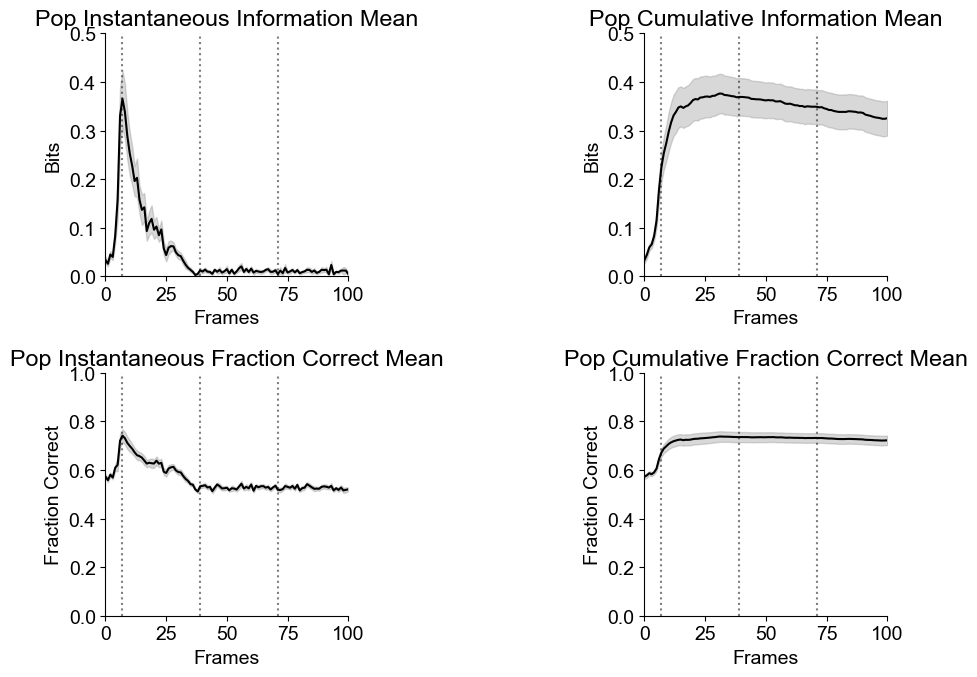

In [177]:
# Plot population decoders across datasets
current_model_type = 'passive'
results_pre_all = results_pass_all_sb 
current_decoder_type = 'photostim'   
os.makedirs(f'{plotter.save_results}/{current_model_type}/', exist_ok=True)

# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop', # or sc
                     save_dir=f'{plotter.save_results}/{current_model_type}', #,save_dir = f'{save_results}/{current_decoder_type}_{current_model_type}_pop'
                     xlim = (0,100),
                     ylim = [0.5, 0.5, 1, 1]) #define y limits for each subplot

In [271]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

def plot_selected_metric_with_sem( mean_results_all, mean_results_all_passive, decoder_type, metric, start_frame = None,end_frame = None, xlim=None, ylim=None, title=None, xlabel='Frames', ylabel=None, colors = ('blue','red'), save_dir=None):
    """
    Plot the selected metric from mean_results_all and mean_results_all_passive on the same plot with SEM shading.
    
    Parameters:
    - mean_results_all: dict, results for the active condition
    - mean_results_all_passive: dict, results for the passive condition
    - decoder_type: str, the type of decoder used
    - metric: str, the metric to plot
    - plot_type: str, type of plot ('sc' for single cell, 'pop' for population)
    - xlim: tuple, x-axis limits
    - ylim: tuple, y-axis limits
    - title: str, title of the plot
    - xlabel: str, label for the x-axis
    - ylabel: str, label for the y-axis
    - save_dir: str, directory to save the plot
    """
    # Get event frames from first dataset
    first_dataset = list(mean_results_all.keys())[0]
    event_frames = mean_results_all[first_dataset][decoder_type]['event_frame_mean']
    
    # Collect data across datasets for active condition
    all_data_active = []
    for dataset in mean_results_all.keys():
        if decoder_type in mean_results_all[dataset]:
            data = mean_results_all[dataset][decoder_type][metric]

            # Average across neurons for sc data
            if 'sc' in metric and len(data.shape) == 2:  # frames x neurons
                data = np.mean(data, axis=1)  # average across neurons

            all_data_active.append(data)
    
    # Collect data across datasets for passive condition
    all_data_passive = []
    for dataset in mean_results_all_passive.keys():
        if decoder_type in mean_results_all_passive[dataset]:
            data = mean_results_all_passive[dataset][decoder_type][metric]

            # Average across neurons for sc data
            if 'sc' in metric and len(data.shape) == 2:  # frames x neurons
                data = np.mean(data, axis=1)  # average across neurons

            all_data_passive.append(data)

    
    if end_frame is None:
        end_frame = data.shape[0]
    if start_frame is None:
        start_frame = data.shape[0]

    used_frames = np.arange(start_frame, end_frame) # frames to use for plotting    
    # Convert lists to NumPy arrays
    all_data_active = np.array(all_data_active)
    all_data_passive = np.array(all_data_passive)
    
    # Calculate mean and SEM for active condition
    all_data_active_final = all_data_active[:,used_frames]
    mean_trace_active = np.mean(all_data_active_final, axis=0)
    sem_trace_active = np.std(all_data_active_final, axis=0) / np.sqrt(len(all_data_active_final))

    # Calculate mean and SEM for passive condition
    all_data_passive_final = all_data_passive[:,used_frames]  
    mean_trace_passive = np.mean(all_data_passive_final, axis=0)
    sem_trace_passive = np.std(all_data_passive_final, axis=0) / np.sqrt(len(all_data_passive_final))

    # Plot the metric values
    plt.figure(figsize=(3.5,3))
    x = np.arange(len(mean_trace_active))
    
    # Plot active condition
    active_line, = plt.plot(mean_trace_active, color=colors[0], label='Active')
    plt.fill_between(x, mean_trace_active - sem_trace_active, mean_trace_active + sem_trace_active, alpha=0.3, color=colors[0]) #, label='Active SEM'
    
    # Plot passive condition
    passive_line, = plt.plot(mean_trace_passive, color=colors[1], label='Passive')
    plt.fill_between(x, mean_trace_passive - sem_trace_passive, mean_trace_passive + sem_trace_passive, alpha=0.3, color=colors[1]) #, label='Passive SEM'
    
    # Add event markers
    for frame in event_frames:
        if frame < len(mean_trace_active):
            plt.axvline(x=frame - start_frame, color='k', linestyle=':', alpha=0.5)
    
    # Formatting
    plt.title(title)
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    else:
        plt.ylabel('Bits' if 'information' in metric else 'Fraction Correct')
    
    plt.xlim(xlim if xlim else (0+ start_frame, len(mean_trace_active)- start_frame))
    if ylim:
        plt.ylim(ylim)
    
     # Add text annotations for the labels
    plt.text(xlim[1]-20, ylim[1], 'Active', color=colors[0], verticalalignment='center')
    plt.text(xlim[1]-20, ylim[1] - ylim[1]*.1, 'Passive', color=colors[1], verticalalignment='center')

    # # Custom legend with colored text
    # legend_labels = ['Active', 'Passive']
    # legend_colors = colors
    # handles = [plt.Line2D([0], [0], color='w', markerfacecolor=color, markersize=10, marker='o') for color in legend_colors]

    # #handles = [active_line, passive_line]
    # legend = plt.legend(handles, legend_labels,shadow = None, frameon = False,   loc='center left', bbox_to_anchor=(1, 0.5)) #loc='upper right',
    # for text, color in zip(legend.get_texts(), legend_colors):
    #     text.set_color(color)

    # plt.legend(shadow = None, frameon = False,  loc='upper right')

    plt.tight_layout()

    # Clean up the appearance
    ax = plt.gca()  # get current axis  
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Save the plot if save_dir is provided
    if save_dir:
        plt.savefig(f"{save_dir}/{metric}_context_comparison_traces.png")
    
    plt.show()
    return mean_trace_active, sem_trace_active, mean_trace_passive, sem_trace_passive

In [326]:
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

def scatter_plot_with_sem(labels, means, sems, colors=['blue', 'red'], title='Scatter Plot', ylabel='Value', save_dir=None):
    """
    Create a scatter plot with error bars (SEM).
    
    Parameters:
    - labels: list of str, labels for the points
    - means: list of float, mean values for each point
    - sems: list of float, standard error of the mean for each point
    - colors: list of str, colors for the points
    - title: str, title of the plot
    - ylabel: str, label for the y-axis
    - save_dir: str, directory to save the plot
    """
    x = np.arange(len(labels))  # the label locations

    fig, ax = plt.subplots(figsize=(3, 3))
    # Set global font size and family 
    plt.rcParams.update({'font.size': 14, 'font.family': 'arial'})
    
    # Plot scatter points with error bars
    for i in range(len(labels)):
        ax.errorbar(x[i], means[i], yerr=sems[i], fmt='o', color=colors[i], capsize=5, markersize=10, label=labels[i])

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    # Clean up the appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()

    # Get the y-axis limits (used for significance stars)
    y_limits = plt.gca().get_ylim()
    x_limits = plt.gca().get_xlim()
    ax.set(ylim=(y_limits[0]*.9,y_limits[1]*1.1))
    ax.set(xlim=(x_limits[0]-1,x_limits[1]+1))
    ax.set_xticklabels(labels,rotation=45)

    # Save the plot if save_dir is provided
    if save_dir:
        plt.savefig(f"{save_dir}_scatter_plot.png", bbox_inches='tight')

    #plt.show()
    return ax, x, y_limits
def simple_bar_plot(labels, means, sems,colors = ['blue','red'], title='Bar Plot', ylabel='Value', save_dir=None):
    """
    Create a simple bar plot with error bars.
    
    Parameters:
    - labels: list of str, labels for the bars
    - means: list of float, mean values for each bar
    - sems: list of float, standard error of the mean for each bar
    - title: str, title of the plot
    - ylabel: str, label for the y-axis
    - save_dir: str, directory to save the plot
    """
    
    x = np.arange(len(labels))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(3,3))
    # Set global font size and family 
    plt.rcParams.update({'font.size': 14, 'font.family': 'arial'})
    bars = ax.bar(x, means, width, yerr=sems, capsize=4, edgecolor= colors, facecolor='white', linewidth=2) #,ecolor=colors

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    # Clean up the appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Get the y-axis limits (used for significance stars)
    y_limits = plt.gca().get_ylim()
    ax.set(ylim=(0,y_limits[1]*1.1))

    fig.tight_layout()

    # Save the plot if save_dir is provided
    if save_dir:
        plt.savefig(f"{save_dir}_bar_plot.png", bbox_inches='tight') #/{title.replace(' ', '_')}

    #plt.show()
    return ax,x, y_limits

def simple_plot_wrapper(data,sem, plot_type = 'bar',colors= ['blue','red'], frames = None, ylabel = 'Mean Value', save_dir = None):
    """ create wrapper for bar plot to calculate significance
     data: list of values for conditions (active, passive) 
     """
    
    # Calculate mean and SEM
    labels = ['Active', 'Passive']
    if frames is None:
        frames = np.arange(len(data))   
    means = list(np.mean(data[:,frames], axis = 1))
    sems = list(np.mean(sem[:,frames], axis = 1)) #, axis = 1

    # Create the bar plot   
    if 'bar' in plot_type:
        ax,x, ymax = simple_bar_plot(labels, means, sems,colors = colors, title= None, ylabel= ylabel, save_dir=save_dir)
    elif 'scatter' in plot_type:
        ax,x, ymax = scatter_plot_with_sem(labels, means, sems, colors=colors, title= None, ylabel=ylabel, save_dir=save_dir)

    # Perform pairwise comparisons
    all_p_values = []
    comparisons = []
    for i in range(data.shape[0]):
        for j in range(i + 1, data.shape[0]):
            stat, p_value = wilcoxon(data[i, frames], data[j, frames])
            all_p_values.append(p_value)
            comparisons.append((i, j))

    corrected_p_values, significance_stars = analysisenc.calculate_bonferroni_significance(all_p_values, alpha=0.05)

    # Add significance stars to the plot
    for (i, j), star in zip(comparisons, significance_stars):
        if star != 'ns':  # Only add significance line if there is a star
            plotter.add_significance_line(ax, x1=x[i], x2=x[j], y=ymax[1], significance=star, color='black')

    plt.show()  # Ensure the plot is updated
    return all_p_values,corrected_p_values


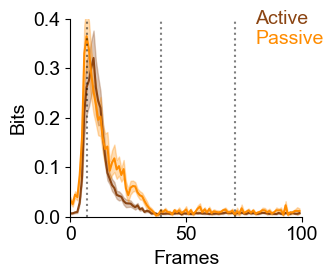

Bonferroni corrected alpha threshold: 0.05000


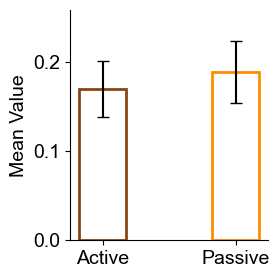

([0.1688232421875], [0.1688232421875])

In [334]:
# Plot population decoders across datasets
current_model_type = 'both'
data_type = 'information' # 'fraction_correct' or 'information'
save_dir_contexts = f'{plotter.save_results}/{current_model_type}_instantaneous_{data_type}'
# results_pre_all = results_pre_all_sb 
current_decoder_type = 'photostim' 
labels = ['Active', 'Passive']
frames_used = np.arange(7,22) #[7,22]   # frames to use for the bar plot 
colors_used =  ['saddlebrown','darkorange'] #['darkslateblue','mediumslateblue'] #colors for the bar plot     
os.makedirs(save_dir_contexts , exist_ok=True)

# Usage example:
mean_trace_active, sem_trace_active, mean_trace_passive, sem_trace_passive = plot_selected_metric_with_sem(results_pre_all_sb, 
                              results_pass_all_sb,
                     decoder_type= current_decoder_type,
                     metric=f'pop_instantaneous_{data_type}_mean', #instantaneous_fraction_correct_mean or information
                     start_frame = 0,
                     end_frame = 100,
                     save_dir=save_dir_contexts, #,save_dir = f'{save_results}/{current_decoder_type}_{current_model_type}_pop'
                     xlim = (0,100),
                     ylim = (0,.4),
                     colors = colors_used) #define y limits for each subplot


data_bar = np.array([mean_trace_active, mean_trace_passive])
sems_bar = np.array([sem_trace_active,sem_trace_passive])


simple_plot_wrapper(data_bar,sems_bar,plot_type = 'bar', colors= colors_used, frames = frames_used, ylabel = 'Mean Value', save_dir = save_dir_contexts)
## Create a bar plot using the outputs
# labels = ['Active', 'Passive']
# frames = [7,21]   # frames to use for the bar plot    
# means = [np.mean(mean_trace_active[frames]), np.mean(mean_trace_passive[frames])]
# sems = [np.mean(sem_trace_active[frames]), np.mean(sem_trace_passive[frames])]

# _,_,_ = simple_bar_plot(labels, means, sems, colors = ['darkslateblue','mediumslateblue'], title=None, ylabel='Mean Value', save_dir=None)

In [297]:
list(np.mean(data_bar[:,frames_used], axis = 1))

[0.6377496687370601, 0.6668660416666666]

In [11]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec(celltype_info)

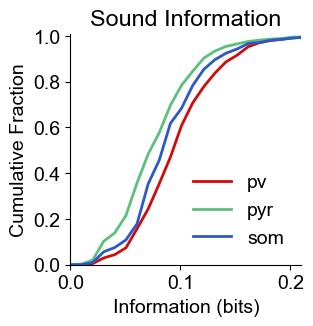

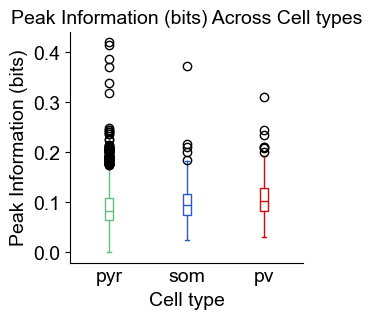

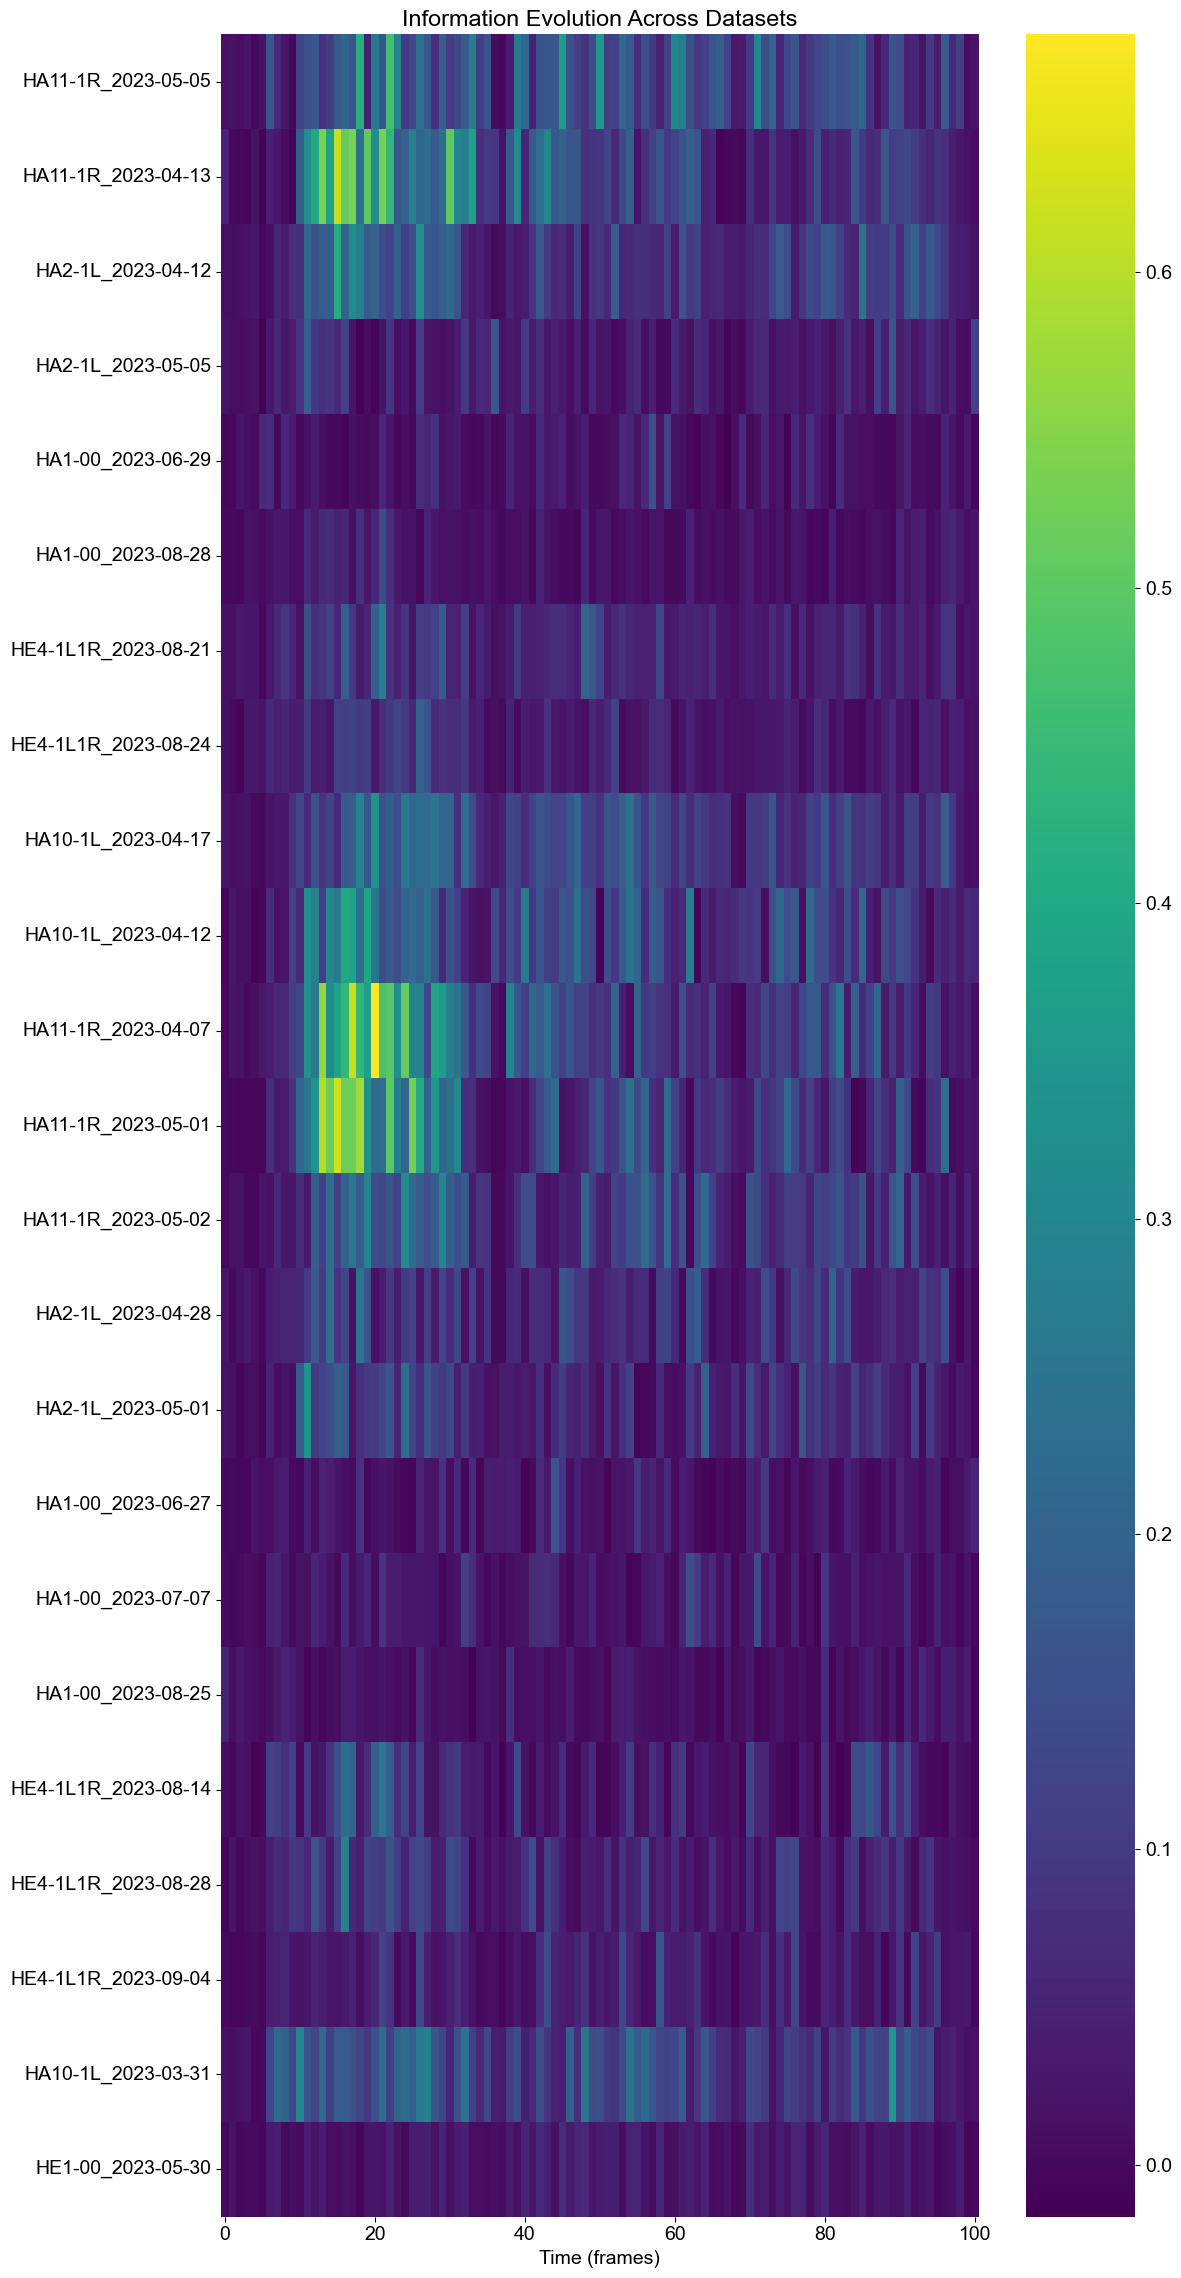

In [186]:
#DECIDE WHETHER OR NOT TO USE END FRAME
start_frame = 14 #before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold = None #use threshold OR percentile to decide signficant neurons
# Replace dot with underscore in threshold for directory name
threshold_str = str(threshold).replace('.', '_')
# save_path = f'{plotter.save_results}/{current_model_type}/{threshold_str}'
# save_path = os.path.join(plotter.save_results, current_model_type, threshold_str)
# print(save_path)
# os.makedirs(save_path, exist_ok=True)
save_path = f'{plotter.save_results}/{current_model_type}/'

peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = 95, threshold = threshold) #, end_frame = 100

#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!
metric_to_plot = 'sc_instantaneous_information_mean'
cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=True)

#cdf
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title='Sound Information',
                                xlabel = 'Information (bits)',
                                xval=.2,
                                xint=0.1,
                                save_path=f'{save_path}{current_decoder_type}_cdf_thr{threshold_str}.png')

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)',
    save_path=f'{save_path}{current_decoder_type}_box_plot_thr{threshold_str}.png'
)

#heatmap across datasets
plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_instantaneous_information_mean')


In [191]:
np.shape(np.where(peaks_by_celltype['HA11-1R_2023-05-05']['pyr']['sc']['sc_cumulative_information_mean']['significant_neurons']))

(1, 163)

In [88]:
# PRINT OUT # OF SIGNIFICANT NEURONS PER CELL TYPE
# Assuming cdf_data is a dictionary with cell types as keys and peaks as values
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')

Cell type: pyr, Number of significant neurons: 3837
Cell type: som, Number of significant neurons: 212
Cell type: pv, Number of significant neurons: 406
Cell type: all, Number of significant neurons: 4455


In [15]:
def visualize_single_neuron_analysis(results_dict,shuffled_structure , plotter, analyzer, decoder_type='sound_category', start_frame=14, end_frame=None, metric = 'sc_instantaneous_information_mean', significance_percentile = 95, threshold = None, save_path=None):
    """Orchestrate single neuron analysis and visualization."""

    significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure, decoder_type, start_frame, end_frame,metric ,significance_percentile)
    
    #using threshold to get significant neurons? threshold_value = 0.06
    if threshold is not None:
        significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame,metric,threshold)
    
    # Extract significant neurons for each dataset
    significant_neurons = {dataset: np.concatenate([significant_neurons_data[dataset][celltype] for celltype in significant_neurons_data[dataset]]) 
                           for dataset in significant_neurons_data}
    
    # Plot the heatmap, only using significant neurons if they exist
    #plotter.plot_neuron_performance_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #separated by datasets

    plotter.plot_significant_neurons_distribution(significance_struc,save_path=save_path) 

    plotter.plot_time_course_by_cell_type(results_dict, decoder_type, start_frame = 0, end_frame = end_frame, metric = metric)

    plotter.plot_summary_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons, save_path=save_path) #combined across datasets

    plotter.plot_significant_neuron_percentages_by_celltype(significant_neurons, celltype_info,  save_path=save_path)

    return significant_neurons_data

In [193]:
def visualize_single_neuron_analysis(results_dict,shuffled_structure , plotter, analyzer, decoder_type='sound_category', start_frame=14, end_frame=None, metric = 'sc_instantaneous_information_mean', significance_percentile = 95, threshold = None, save_path=None):
    """Orchestrate single neuron analysis and visualization."""

    significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure, decoder_type, start_frame, end_frame,metric ,significance_percentile)
    
    #using threshold to get significant neurons? threshold_value = 0.06
    if threshold is not None:
        significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame,metric,threshold)
    
    # Extract significant neurons for each dataset
    significant_neurons = {dataset: np.concatenate([significant_neurons_data[dataset][celltype] for celltype in significant_neurons_data[dataset]]) 
                           for dataset in significant_neurons_data}
    
    # Plot the heatmap, only using significant neurons if they exist
    #plotter.plot_neuron_performance_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #separated by datasets

    plotter.plot_significant_neurons_distribution(significance_struc) 

    plotter.plot_time_course_by_cell_type(results_dict, decoder_type, start_frame = 0, end_frame = end_frame, metric = metric)

    plotter.plot_summary_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #combined across datasets

    plotter.plot_significant_neuron_percentages_by_celltype(significant_neurons, celltype_info,  save_path=save_path)

    return significant_neurons_data, significance_struc

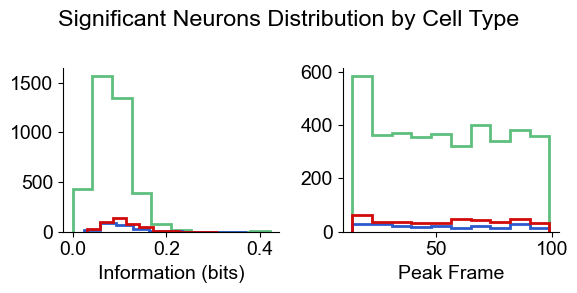

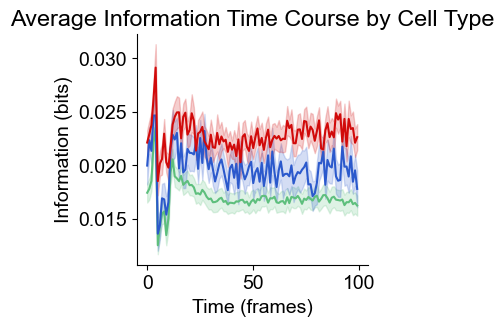

c:\Code\Github\GLM-analysis\Plotter.py:1216: RuntimeWarning: invalid value encountered in divide
  normalized_data = data / max_values  # Normalize by Imax for each neuron


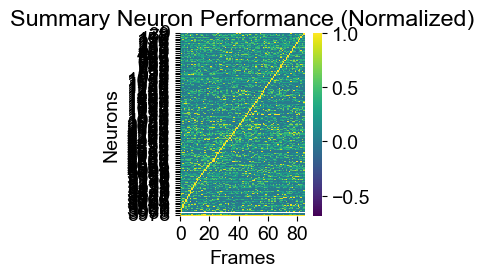

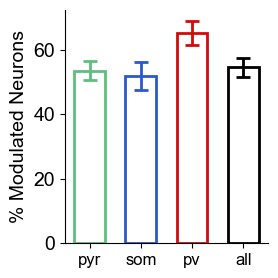

Significantly Modulated Neurons (% ± SEM):
pyr: 53.58 ± 2.91%
som: 51.88 ± 4.37%
pv: 65.21 ± 3.77%
all: 54.63 ± 2.90%


In [ ]:
# Call the visualization function
threshold = None
significant_neurons_data, sig_struct = visualize_single_neuron_analysis(
    results_dict=results_pre_all,
    shuffled_structure = shuffled_structure,
    plotter=plotter,
    analyzer =analysis_dec,
    decoder_type = current_decoder_type,  # Or your preferred decoder type
    start_frame = 14,                 # Specify start frame
    end_frame = 100,                    # Specify end frame if needed, else None
    metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
    significance_percentile = 95,         #used to determine significant cells
    threshold = threshold ,                   #None or 0.06 (from Runyan 2017)
    save_path= f'{save_path}{current_decoder_type}_sig_cel_thr{str(threshold)}.png'
)

# # Save significant neurons data to a .mat file
# mat_file_path = os.path.join(save_path, f'significant_neurons_data_none.mat')
# sp.io.savemat(mat_file_path, significant_neurons_data)


In [197]:
np.shape(sig_struct['HA11-1R_2023-05-05']['pyr']['peak_values'])

(228,)

In [162]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])

# Prepare data for saving
matlab_data = {}
for dataset, celltypes in significant_neurons_data.items():
    print(dataset)
    sanitized_dataset = sanitize_field_name(dataset)
    matlab_data[sanitized_dataset] = {}
    for celltype, indices in celltypes.items():
        sanitized_celltype = sanitize_field_name(celltype)
        
        if indices is None:
            peaks = [peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_values'][index] for index in indices]
            # Add one to each index for MATLAB indexing
            indices = [index + 1 for index in indices]
        matlab_data[sanitized_dataset][sanitized_celltype] = {
            'indices': indices,
            'peaks': peaks
        }
# # Prepare data for saving
# matlab_data = {}
# for dataset, celltypes in significant_neurons_data.items():
#     sanitized_dataset = sanitize_field_name(dataset)
#     matlab_data[sanitized_dataset] = {}
#     for celltype, data in celltypes.items():
#         sanitized_celltype = sanitize_field_name(celltype)
#         matlab_data[sanitized_dataset][sanitized_celltype] = [index + 1 for index in indices]  # Save indices of significant neurons 

# Save significant neurons data to a .mat file
mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, matlab_data)
print(f'Significant neurons data saved to {mat_file_path}')

HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA10-1L_2023-03-31
HE1-00_2023-05-30
Significant neurons data saved to V:/Connie/results/glm_decoding/prelim/passive/significant_neurons_data.mat


In [192]:
np.shape(significant_neurons_data['HA11-1R_2023-05-05']['pyr'])

(228,)

In [117]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])
# Print the number of significant neurons per cell type and prepare data for saving
significant_neurons_data = {}
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')
        sanitized_cell_type = sanitize_field_name(cell_type)
        significant_neurons_data[sanitized_cell_type] = {
            'num_significant_neurons': num_significant_neurons,
            'peaks': np.array(data['peaks'])
        }

mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, significant_neurons_data)

Cell type: pyr, Number of significant neurons: 3837
Cell type: som, Number of significant neurons: 212
Cell type: pv, Number of significant neurons: 406
Cell type: all, Number of significant neurons: 4455


In [ ]:
start_frame = 14 #before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold = None #use threshold OR percentile to decide signficant neurons
# Replace dot with underscore in threshold for directory name
threshold_str = str(threshold).replace('.', '_')

results_dict=results_pre_all
plotter=plotter
analyzer =analysis_dec
decoder_type = current_decoder_type  # Or your preferred decoder type
start_frame = 14                 # Specify start frame
end_frame = 100                  # Specify end frame if needed, else None
metric = 'sc_instantaneous_information_mean' #choose sc metric to look at
significance_percentile = 95         #used to determine significant cells


peaks_by_celltype_test = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure_pass,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = 95, threshold = threshold) #, end_frame = 100


significant_neurons_data_test, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure_pass, decoder_type, start_frame, end_frame,metric ,significance_percentile)

In [233]:
def analyze_significant_neurons_test( results_dict, shuffled_structure, decoder_type, start_frame, end_frame, metric='sc_instantaneous_information_mean', significance_percentile=95, threshold = None):
    """Analyze significant neurons for plotting."""
    neuron_ids_by_dataset = {}
    significance_struc = {}
    peaks_by_celltype = analyzer.analyze_peaks_by_celltype(results_dict, shuffled_structure, decoder_type, start_frame, end_frame, significance_percentile, threshold)

    for dataset in results_dict:
        neuron_ids_by_dataset[dataset] = {}
        significance_struc[dataset] = {}
        
        for celltype in peaks_by_celltype[dataset]:
            neuron_ids_by_dataset[dataset][celltype] = []

            # Ensure initialization of significance_struc[dataset][celltype]
            significance_struc[dataset][celltype] = {}
            # Extract significant neurons
            significant_neurons = peaks_by_celltype[dataset][celltype]['sc'][metric]['significant_neurons']
            neuron_ids_by_dataset[dataset][celltype] = np.where(significant_neurons)[0].tolist()
            print(f"[analyze_significant_neurons] Dataset: {dataset}, Celltype: {celltype}, Significant Neurons: {neuron_ids_by_dataset[dataset][celltype]}")
            # Add peak data for significant neurons
            significant_indices = neuron_ids_by_dataset[dataset][celltype]
            significance_struc[dataset][celltype]['peak_values'] = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_values'][significant_indices]
            significance_struc[dataset][celltype]['peak_frames'] = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_frames'][significant_indices]
            print(f"[analyze_significant_neurons] Dataset: {dataset}, Celltype: {celltype}, Peak Values: {significance_struc[dataset][celltype]['peak_values']}")

    return neuron_ids_by_dataset, significance_struc

neuron_ids_by_dataset_test, significance_struc_test = analyze_significant_neurons_test(results_dict, shuffled_structure_pass, decoder_type, start_frame, end_frame, metric, significance_percentile, threshold = 0.1)    

[analyze_significant_neurons] Dataset: HA11-1R_2023-05-05, Celltype: pyr, Significant Neurons: [1, 13, 14, 18, 25, 26, 31, 34, 37, 42, 49, 56, 62, 65, 76, 77, 79, 80, 82, 87, 88, 90, 92, 98, 103, 108, 111, 112, 127, 141, 146, 165, 172, 181, 191, 193, 198, 203, 214, 215, 226, 227, 229, 232, 237, 244, 257, 260, 261, 263, 268, 271, 287, 294, 295, 300, 305, 314, 315, 318, 326]
[analyze_significant_neurons] Dataset: HA11-1R_2023-05-05, Celltype: pyr, Peak Values: [0.10423688 0.1126506  0.10572008 0.14128084 0.13036414 0.12220593
 0.10872464 0.18937827 0.11950315 0.18436243 0.20521085 0.11910133
 0.10184481 0.143469   0.10196266 0.15610707 0.14405931 0.1080673
 0.10199751 0.11199777 0.11482599 0.11626036 0.12646852 0.11063549
 0.10761787 0.10196266 0.11799908 0.10468631 0.10054916 0.1084134
 0.11310003 0.10775606 0.18958304 0.10613466 0.10037611 0.10789547
 0.11799908 0.14033314 0.18533529 0.10185932 0.14843769 0.15421626
 0.12182858 0.11524057 0.20622369 0.12251718 0.10199751 0.10178961
 0.

In [239]:
def analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame, metric='sc_instantaneous_information_mean', threshold=0.5):
        """Analyze significant neurons by threshold, looping through cell types defined in self.cell_types."""
        neuron_ids_by_dataset = {}
        significance_struc = {}

        for dataset in results_dict:
            neuron_ids_by_dataset[dataset] = {}
            significance_struc[dataset] = {}

            # Get the indices for neurons of this cell type
            celltype_array = analyzer.celltype_data[dataset]['celltype_array']
            # Get indices for each cell type
            celltype_indices = {
                'pyr': np.where(celltype_array == 0)[0],
                'som': np.where(celltype_array == 1)[0],
                'pv': np.where(celltype_array == 2)[0]
            }

            data = results_dict[dataset][decoder_type][metric]

            if end_frame is None:
                end_frame = data.shape[0]

            # Extract the data within the specified frames
            data_in_range = data[start_frame:end_frame, :]

            # Loop through cell types defined in self.cell_types
            for celltype, indices in celltype_indices.items(): #for celltype in self.cell_types:
                neuron_ids_by_dataset[dataset][celltype] = []
                significance_struc[dataset][celltype] = {}

                
                celltype_indices = indices  # Assuming this is a list/array of indices

                if len(celltype_indices) == 0:
                    continue  # Skip if no neurons of this cell type

                # Subset the data for the current cell type
                data_celltype = data_in_range[:, celltype_indices]
                

                # Find neurons that exceed the threshold at any point in the range
                significant_neurons = np.any(data_celltype > threshold, axis=0)
                neuron_ids = np.array(celltype_indices)[np.where(significant_neurons)[0]].tolist()
                print(neuron_ids)
                neuron_ids_by_dataset[dataset][celltype] = neuron_ids

                # Collect additional information for the significant neurons
                significance_struc[dataset][celltype]['peak_values'] = np.max(data_celltype[:, significant_neurons], axis=0)
                significance_struc[dataset][celltype]['peak_frames'] = np.argmax(data_celltype[:, significant_neurons], axis=0) + start_frame

        return neuron_ids_by_dataset, significance_struc

neuron_ids_by_dataset_test, significance_struc_test = analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame, metric, threshold = 0.1) 

[23, 39, 40, 45, 53, 54, 60, 64, 67, 73, 83, 90, 96, 99, 111, 114, 117, 118, 120, 125, 126, 128, 130, 137, 142, 147, 150, 151, 167, 185, 190, 210, 217, 228, 239, 241, 246, 251, 263, 264, 275, 276, 278, 282, 287, 297, 312, 315, 316, 318, 323, 326, 344, 351, 353, 358, 363, 372, 373, 376, 384]
[172, 300]
[0, 2, 6, 9, 13, 15, 16, 18, 19, 20, 26, 37, 38, 59, 74, 81, 103, 112, 163, 225]
[15, 17, 19, 20, 24, 25, 26, 29, 41, 43, 50, 58, 66, 72, 73, 78, 80, 83, 85, 87, 88, 104, 108, 123, 138, 140, 144, 164, 166, 171, 172, 191, 195, 199, 210, 212, 218, 234, 236, 241, 248, 257, 260, 263, 272, 276, 280, 292, 297, 298, 301, 302, 312, 313, 319, 320, 329, 331, 335, 337, 357, 360, 361, 366, 368, 370, 375, 377, 378]
[]
[0, 3, 5, 6, 8, 9, 12, 13, 49, 63, 70, 141, 305, 380]
[17, 20, 31, 32, 44, 51, 129, 145, 179, 184, 188, 197, 205, 213, 232, 233, 260, 266, 268, 274, 287, 293, 299, 301, 308, 310, 336, 347, 349, 371]
[370]
[5, 7, 80, 111, 324]
[21, 22, 27, 28, 30, 35, 42, 44, 58, 59, 66, 69, 72, 87, 112, 